## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [14]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


98 species total, 44 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.65, Stddev: 1.53, Count of HOGs: 5269
Log odds ratios of DUPLICATION: 
 Mean: 0.03, Stddev: 0.96, Count of HOGs: 7875

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 95 for loss test **
** Minimum occupancy set to 50 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [06:03<00:00, 27.49it/s]


Permulation counter for MEANS:
 Loss: 1909, Duplication: 3303
Filtering log odds ratio results df for occupancy and significance
Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 50; max occupancy (loss): 95
Analysis run on 2026-04-13 at 04:53:17
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269 (loss), 7875 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.650
True standard deviation, loss: 1.525
True mean, duplication: 0.032
True standard deviation, duplication: 0.957

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.191
Probability that the null

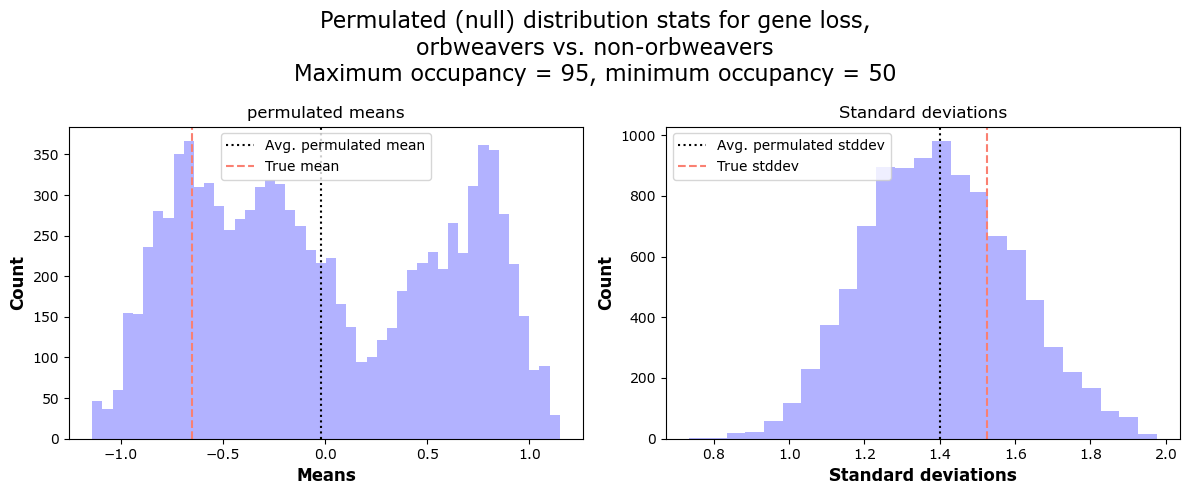

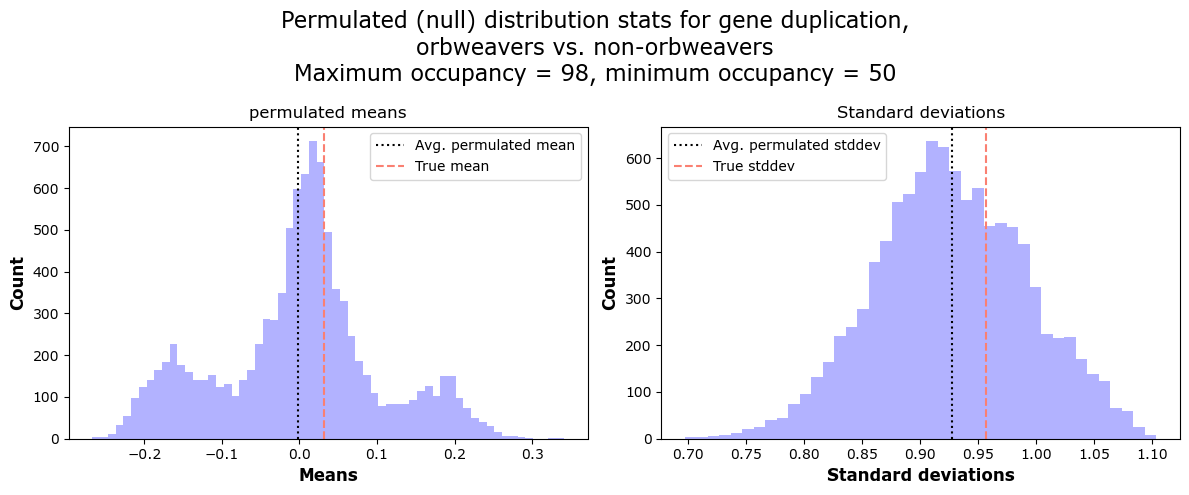

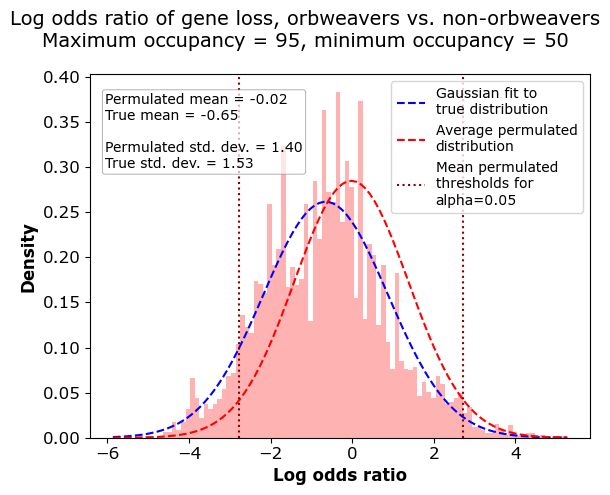

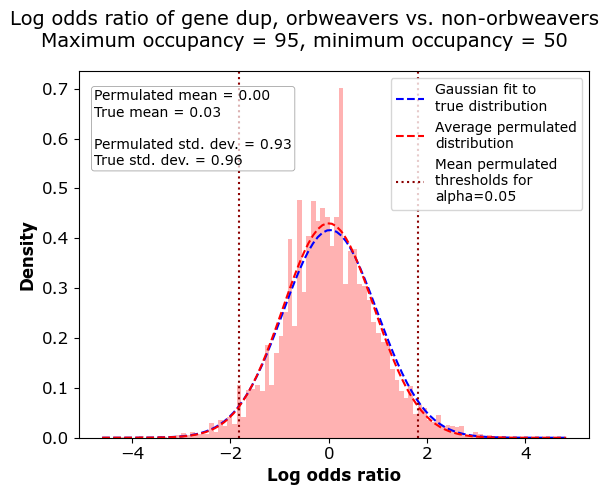

In [ ]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=50,
    max_occ=95,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

In [70]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x")
results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/results.pkl')

In [71]:
%autoreload 2
results._get_hits_dfs()
results.results_fltrd_dfs['loss_bg'][results.results_fltrd_dfs['loss_bg']['Significant in permulation test'] == True]

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0005390,80,-3.721866,0.485841,0.9766,0.0234,0.2562,0.7438,True
N5.HOG0007812,71,-4.406222,3.240331,0.9916,0.0084,0.0737,0.9263,True
N5.HOG0008379,65,-3.654881,0.702673,0.9985,0.0015,0.2486,0.7514,True
N5.HOG0011852,77,-3.958672,0.572593,0.9824,0.0176,0.2483,0.7517,True
N5.HOG0014831,77,-2.819288,0.198632,0.9858,0.0142,0.4540,0.5458,True
...,...,...,...,...,...,...,...,...
N5.HOG0070024,56,-4.498297,2.628111,0.9873,0.0127,0.0056,0.9944,True
N5.HOG0070094,63,-3.271116,0.682614,0.9784,0.0216,0.2899,0.7101,True
N5.HOG0070237,68,-2.892550,1.208444,0.9926,0.0074,0.1754,0.8246,True


In [80]:
%autoreload 2
results.print_permulation_results()

*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 50; max occupancy (loss): 95
Analysis run on 2026-04-13 at 04:53:17
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269 (loss), 7875 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.650
True standard deviation, loss: 1.525
True mean, duplication: 0.032
True standard deviation, duplication: 0.957

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.191
Probability that the null is true for MEAN, duplication (alt=greater): 0.330

Permulated average mean, loss: -0.021
Permulated average standard deviation, loss: 1.401
Permulated average mean, duplica

In [79]:
%autoreload 2

results.save_go_lists(results_dir=ort_dir, use_perm_pvals=True)

Wrote 93 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/loss_fg_sig_locs.txt
Wrote 295 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/loss_bg_sig_locs.txt
Wrote 176 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/dup_fg_sig_locs.txt
Wrote 170 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/dup_bg_sig_locs.txt
Wrote 16 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/loss_fg_perm_pval_sig_locs.txt
Wrote 155 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/loss_bg_perm_pval_sig_locs.txt
Wrote 70 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr13/Run2_occ_50-95_10000x/dup_fg_perm_pval_sig_locs.txt
Wrote 60 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Ap

Save hit lists for GO enrichment

In [64]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Mar25")

# Loss results
loss_results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/Run1_Loss_LT_50-95_10000x/loss_occ50-95_less.pkl')
loss_df = loss_results.results_fltrd_df
loss_orb = loss_df[loss_df["Log odds ratio"] > 0]
loss_nonorb = loss_df[loss_df["Log odds ratio"] < 0]

# Duplication results
dup_results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/Run2_Dup_RT_50-max_10000x/duplication_occ50-98_greater.pkl')
dup_df = dup_results.results_fltrd_df
dup_orb = dup_df[dup_df["Log odds ratio"] > 0]
dup_nonorb = dup_df[dup_df["Log odds ratio"] < 0]

In [34]:
loss_orb_locs_df = convert_hogs_to_locs(loss_orb, os.path.join(repo_root, "data/N5.tsv"))
loss_orb_locs_list = loss_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_orb_locs_list)

Processing HOGs:   0%|          | 0/89 [00:00<?, ?it/s]

93

In [32]:
loss_nonorb_locs_df = convert_hogs_to_locs(loss_nonorb, os.path.join(repo_root, "data/N5.tsv"))
loss_nonorb_locs_list = loss_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_nonorb_locs_list)

Processing HOGs:   0%|          | 0/296 [00:00<?, ?it/s]

295

In [33]:
dup_orb_locs_df = convert_hogs_to_locs(dup_orb, os.path.join(repo_root, "data/N5.tsv"))
dup_orb_locs_list = dup_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_orb_locs_list)

Processing HOGs:   0%|          | 0/179 [00:00<?, ?it/s]

176

In [35]:
dup_nonorb_locs_df = convert_hogs_to_locs(dup_nonorb, os.path.join(repo_root, "data/N5.tsv"))
dup_nonorb_locs_list = dup_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_nonorb_locs_list)

Processing HOGs:   0%|          | 0/173 [00:00<?, ?it/s]

170

In [36]:
list_names = ['loss_orb', 'loss_nonorb'] 
lists = [loss_orb_locs_list, loss_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/odds_ratio_test/loss/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

list_names = ['duplication_orb', 'duplication_nonorb']
lists = [dup_orb_locs_list, dup_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/odds_ratio_test/duplication/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

Wrote 93 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/loss/loss_orb.txt
Wrote 295 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/loss/loss_nonorb.txt
Wrote 176 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/duplication/duplication_orb.txt
Wrote 170 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/duplication/duplication_nonorb.txt
